In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

In [2]:
df = pd.read_csv("donnees_mpox_RDC_3000.csv")
df

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


# A. ANALYSE EXPLORATOIRE APPROFONDUE 

# 1. VERIFICATION DE VALEURS MANQUANTES  

In [3]:
count = df.isnull().sum()
print(count)

ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64


In [11]:
df.columns = df.columns.str.strip()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             3000 non-null   int64  
 14  Saison  

# 2. STATISTIQUES DESCRIPTIVES

In [17]:
df.drop(columns=['ID','Semaine', 'Province']).describe()

,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,157.779667,24.980367,0.451182,71.571667,119.100333,31.843967,286.143333,15.558333,0.40000,5.018000,79.603333,5471.297667,27.041943
std,101.958774,3.832510,0.157799,11.625285,95.218460,14.079517,88.256194,15.139386,0.48998,1.954213,70.119799,2636.188129,20.156959
min,2.000000,18.000000,0.103000,40.000000,5.000000,5.600000,90.000000,1.000000,0.00000,1.000000,0.000000,1001.000000,0.000000
25%,77.000000,22.300000,0.331000,64.000000,48.000000,20.800000,220.000000,5.000000,0.00000,4.000000,29.000000,3127.000000,11.430000
50%,136.000000,24.900000,0.452000,71.500000,94.000000,30.400000,280.000000,11.000000,0.00000,5.000000,57.000000,5514.500000,21.455000
75%,221.000000,27.600000,0.576000,80.000000,163.000000,41.525000,340.000000,22.000000,1.00000,6.000000,109.000000,7819.250000,38.070000
max,400.000000,34.000000,0.795000,95.000000,500.000000,77.800000,800.000000,142.000000,1.00000,10.000000,479.000000,9997.000000,95.000000


# TRANSFORMATION DES VARIABLES TEXTUELLES EN NUMERIQUES 

In [30]:
df['Saison_num'] = df['Saison'].map({'Seche': 0, 'Pluie': 1})

# 3. MATRICE DE CORRELATION 

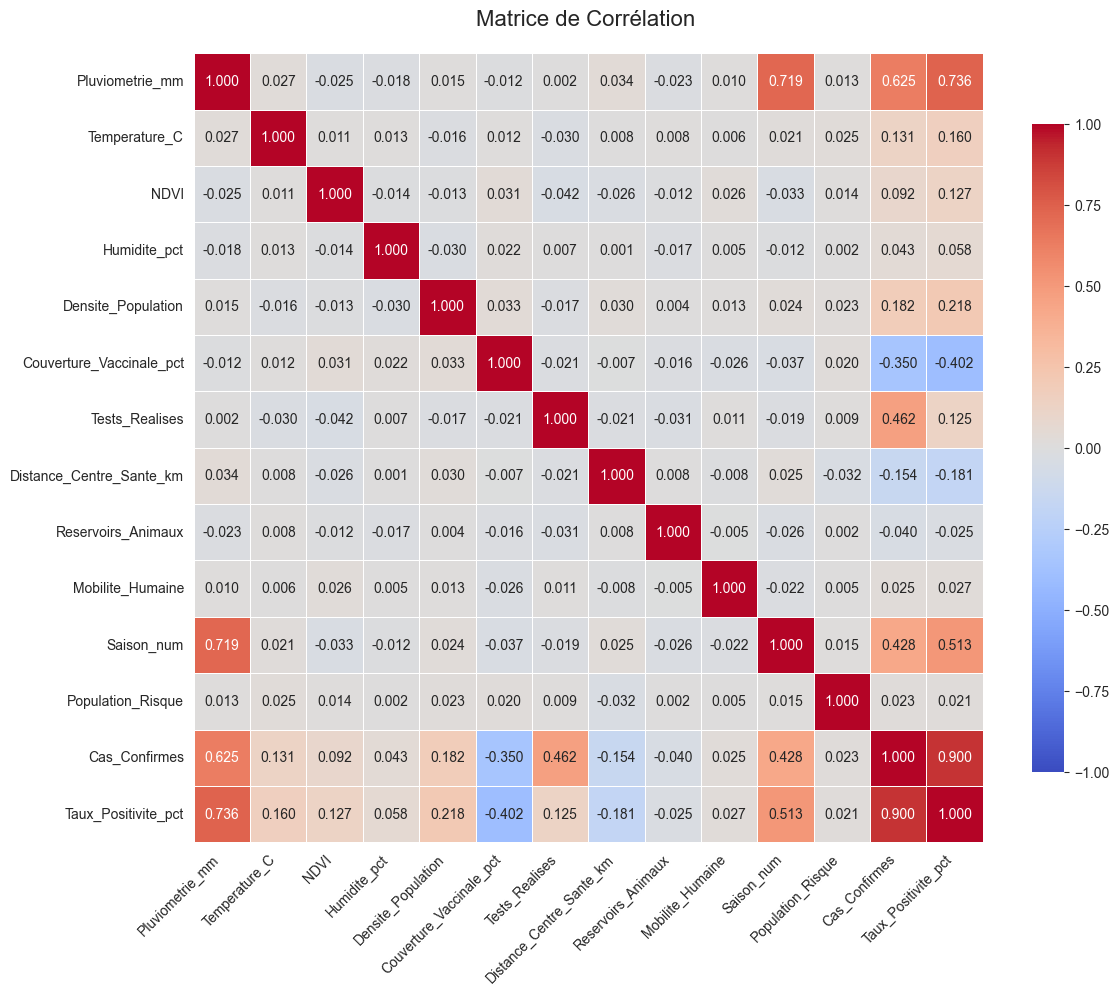

In [31]:
corr_matrix = df[['Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 
    'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Saison_num','Population_Risque', 'Cas_Confirmes', 'Taux_Positivite_pct']].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": .8} )

plt.title("Matrice de Corrélation ", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# INTERPRETATION:

Les variables suivantes ont une relation linaire avec les Cas confirmés de Mpox:
- Pluviometrie_mm (r=0.625): il y a une très forte corrélation positive, plus il pleut , plus il y a les cas confirmés de Mpox;
- Tests_Realises (r=0.462): il y a une corrélation positive modérée, plus on teste , plus on trouve de cas confirmés;
- Saison_num (r=0.428): le passage de la saison sèche à la saison de pluie est associé au nombre de cas confirmés de Mpox;
 

# 4. DISTRIBUTION DES VARIABLES (Histogrammes + KDE) 

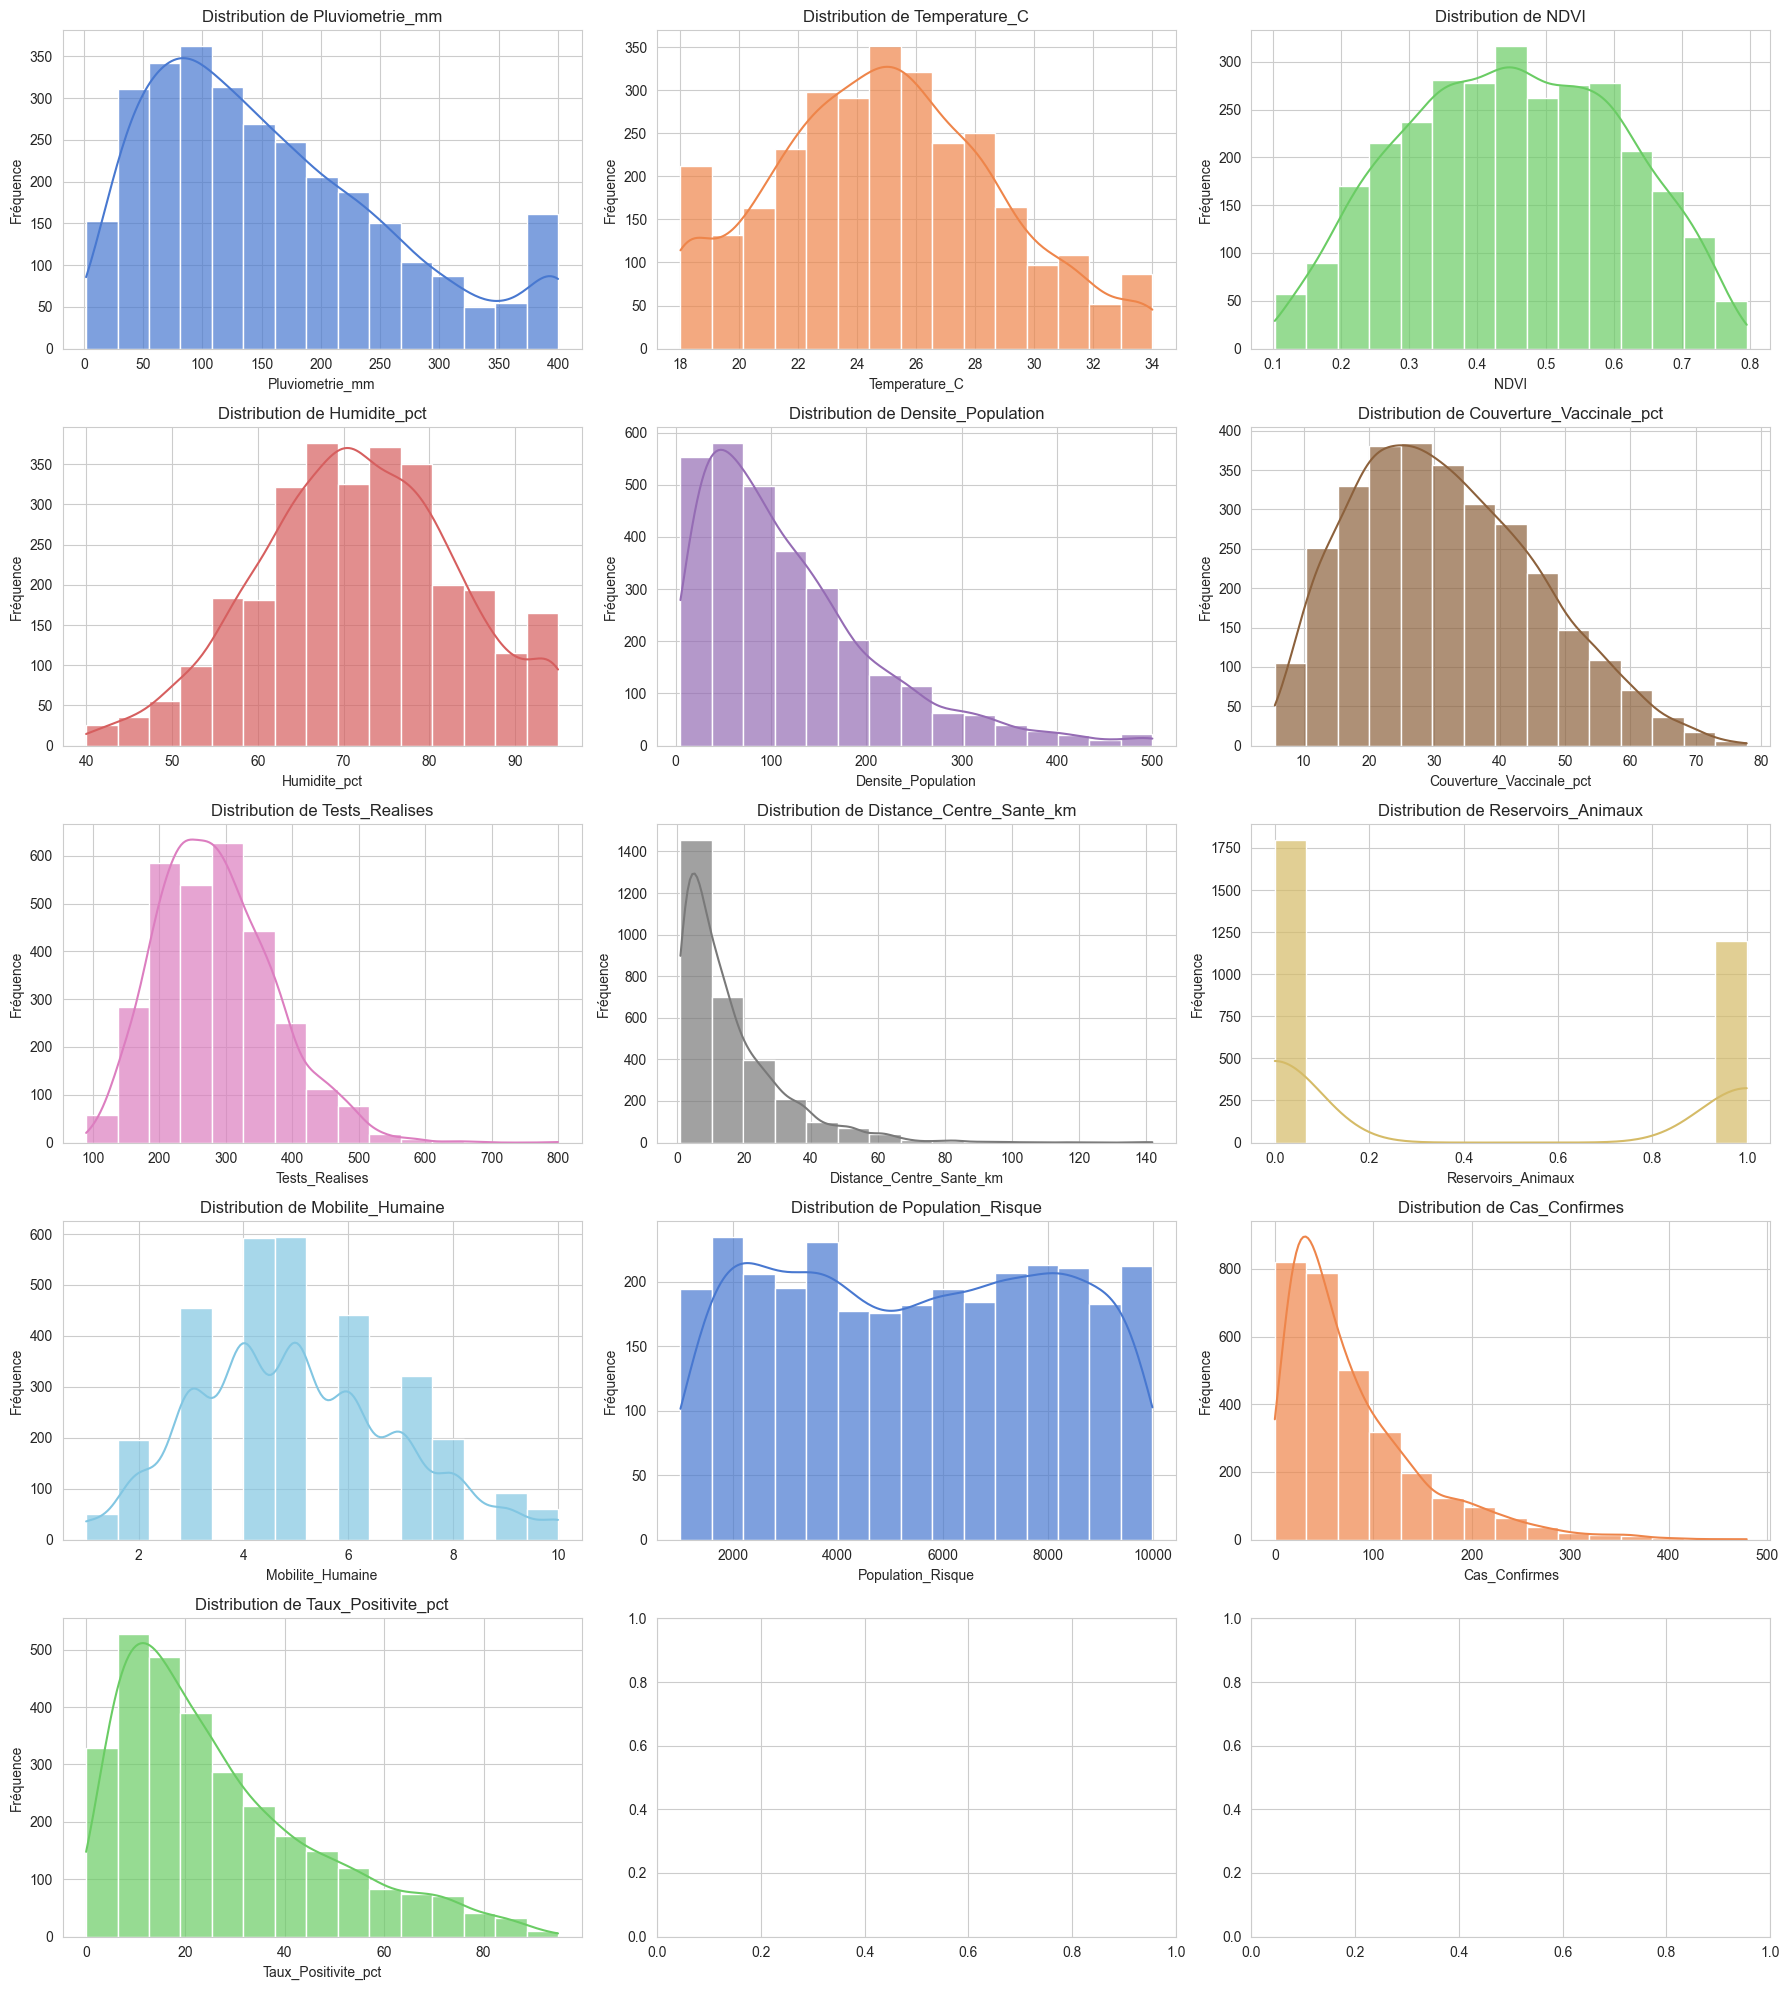

In [34]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

variables = ['Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 
    'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Population_Risque', 'Cas_Confirmes', 'Taux_Positivite_pct']
# couleurs = ['steelblue', 'coral', 'forestgreen', 'goldenrod', 'purple', 'teal']
couleurs = sns.color_palette("muted", len(variables))

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.histplot(df[var], kde=True, ax=axes[i], color=color, bins=15, alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# DETECTION DES OUTLIERS

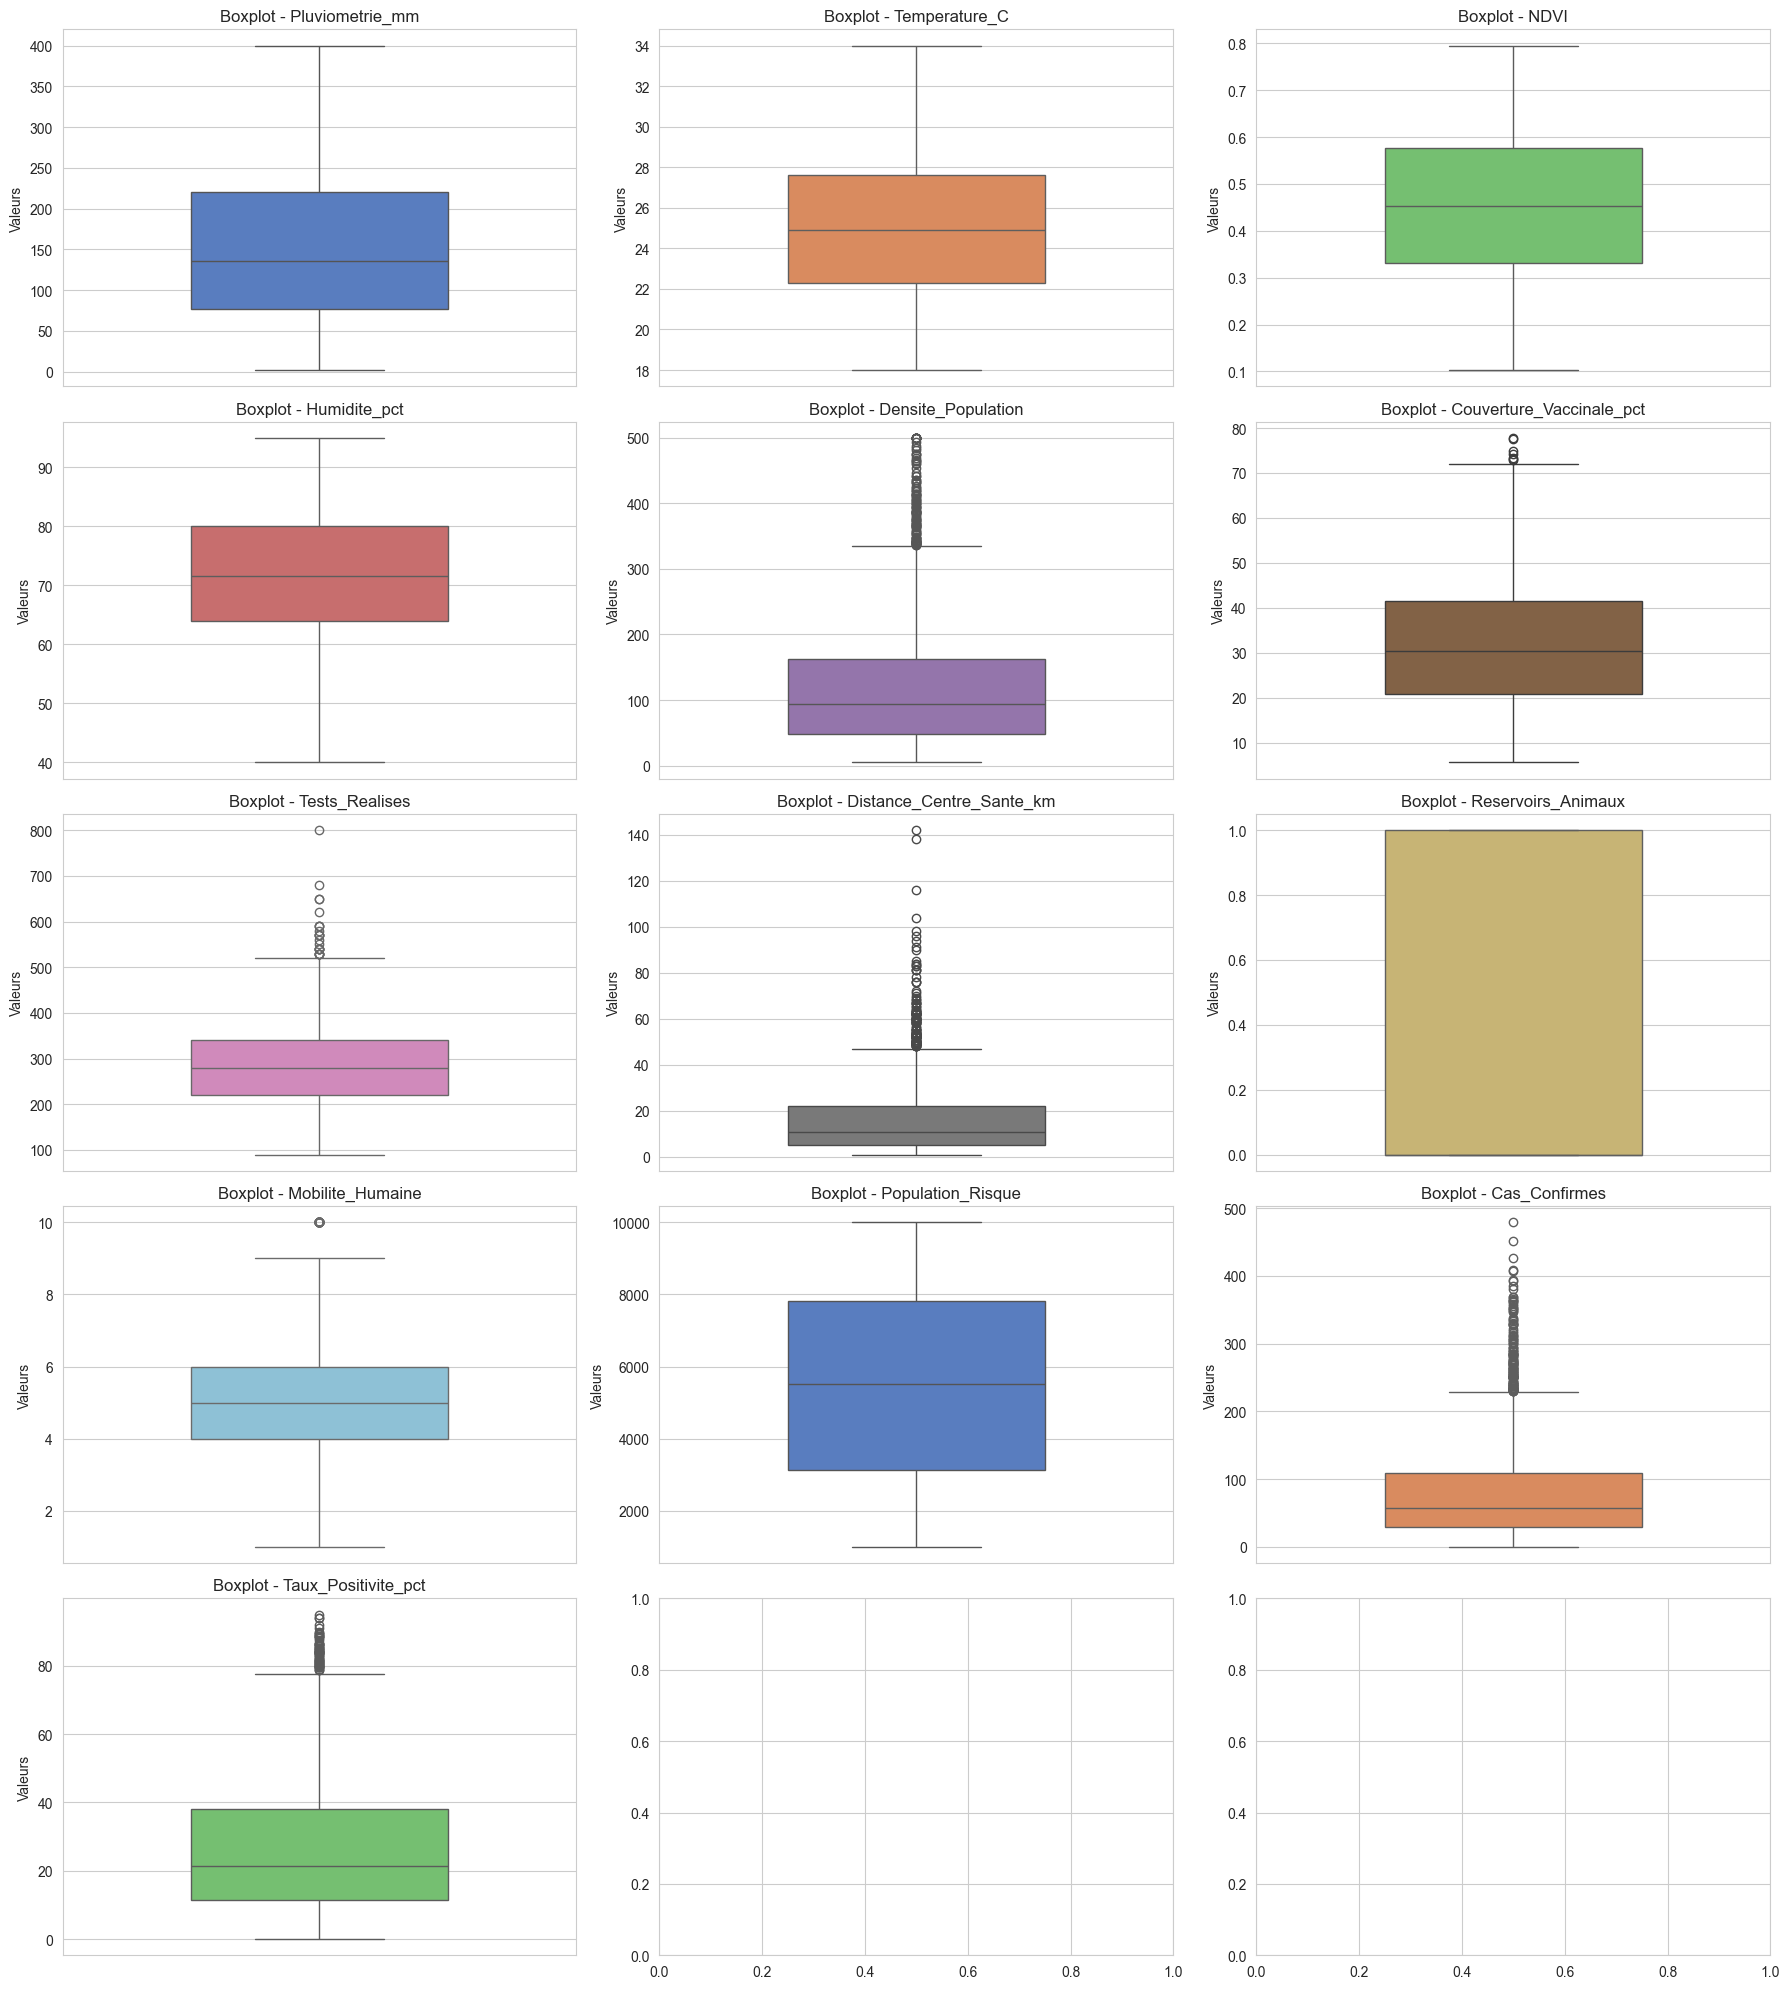

In [35]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.boxplot(y=df[var], ax=axes[i], color=color, width=0.5)
    axes[i].set_title(f'Boxplot - {var}')
    axes[i].set_ylabel('Valeurs')

plt.tight_layout()
plt.show()

#  LA NORMALISATION DES DONNEES 

In [58]:
df_scaler = df.copy()

cols_a_normaliser = [col for col in df.columns if col not in ['ID', 'Semaine', 'Province','Cas_Confirmes', 'Saison_num', 'Saison']]

minmax = MinMaxScaler()
df_scaler[cols_a_normaliser] = minmax.fit_transform(df[cols_a_normaliser])

df_scaler

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct,Saison_num
0,OBS_00001,1,Mongala,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,29,Pluie,0.275345,0.203474,1
1,OBS_00002,2,Kinshasa,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,42,Seche,0.301467,0.147368,0
2,OBS_00003,3,Kinshasa,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,20,Seche,0.425967,0.067895,0
3,OBS_00004,4,Mai-Ndombe,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,82,Pluie,0.308582,0.411053,1
4,OBS_00005,5,Kasaï,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,24,Pluie,0.933193,0.097158,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,0.675879,0.85000,0.622832,0.872727,0.105051,0.232687,0.183099,0.226950,1.0,0.666667,125,Pluie,0.240663,0.598105,1
2996,OBS_02997,2997,Sud-Ubangi,0.216080,0.41250,0.229769,1.000000,0.084848,0.394737,0.394366,0.042553,1.0,0.555556,70,Seche,0.566696,0.199158,0
2997,OBS_02998,2998,Bas-Uele,0.668342,0.47500,0.891618,0.327273,0.026263,0.502770,0.140845,0.156028,0.0,0.111111,36,Pluie,0.497332,0.199474,1
2998,OBS_02999,2999,Haut-Uele,0.525126,0.43125,0.134393,0.672727,0.046465,0.069252,0.394366,0.007092,0.0,0.111111,160,Pluie,0.423744,0.455158,1


# B. KDD 

# 1. SEPARATION DE DONNEES  

In [59]:
X = df_scaler.drop(columns=['Cas_Confirmes', 'ID', 'Province', 'Saison', 'Semaine', 'Taux_Positivite_pct'], errors='ignore')
y = df_scaler['Cas_Confirmes']

In [60]:
X

,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Population_Risque,Saison_num
0,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,0.275345,1
1,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,0.301467,0
2,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,0.425967,0
3,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,0.308582,1
4,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,0.933193,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.675879,0.85000,0.622832,0.872727,0.105051,0.232687,0.183099,0.226950,1.0,0.666667,0.240663,1
2996,0.216080,0.41250,0.229769,1.000000,0.084848,0.394737,0.394366,0.042553,1.0,0.555556,0.566696,0
2997,0.668342,0.47500,0.891618,0.327273,0.026263,0.502770,0.140845,0.156028,0.0,0.111111,0.497332,1
2998,0.525126,0.43125,0.134393,0.672727,0.046465,0.069252,0.394366,0.007092,0.0,0.111111,0.423744,1


# 2. DECOUPAGE STRATIFIE 

In [72]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['Province'])

# 3. ENTRAINEMENT DU MODELE DE REGRESSION LINEAIRE MULTIVARIEE

In [73]:
model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
bo = (model_LRM.intercept_).round(3)
bo

np.float64(-69.23)

In [75]:
coef = (model_LRM.coef_).round(3)
coef

array([ 183.893,   39.99 ,   41.626,   20.539,   73.93 , -127.557,
        265.728, -112.924,   -1.307,   -1.676,    1.545,   -7.701])

# INTERPRETATION
Toute chose égale par ailleur,
-  Les nombres de cas suspects influencent les cas confirmés avec un taux de 0.769
- La Pluviometrie_mm influence les cas confirmés avec un taux de 0.135
-La Temperature_C influence les cas confirmés avec un taux de 0.02
- La Deforestation_ha influence les cas confirmés avec un taux de 0.024
- NDVI influence les cas confirmés avec un taux de -0.013 c.a.d le NDVI constitue un facteur protecteur pour le M-pox


# 4. MODELE METRIQUES D'EVALUATION DE PERFORMANCE DU MODELE 

In [85]:
def evaluate_model(model_LRM, X_train, X_test, y_train, y_test, model_name):
    """Évalue un modèle, applique le seuil de positivité et calcule les métriques."""
    
    # Validation croisée sur le train set
    cv_scores = cross_val_score(model_LRM, X_train, y_train, cv=5, scoring='r2')
    
    # Entraînement et prédictions
    model_LRM.fit(X_train, y_train)
    y_pred = model_LRM.predict(X_test)
    
    y_pred_corrected = np.clip(y_pred, 0, None) # Correction indispensable (pas de cas négatifs)
    
    # Calcul des métriques
    metrics = {
        'R²': r2_score(y_test, y_pred_corrected),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_corrected)),
        'MAE': mean_absolute_error(y_test, y_pred_corrected),
        'CV R² moyen': cv_scores.mean(),
        'CV R² écart-type': cv_scores.std()}

    print(f"\n{model_name}:")
    print(f"  R²: {metrics['R²']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.2f} (cas)")
    print(f"  MAE: {metrics['MAE']:.2f} (cas)")
    print(f"  CV R²: {metrics['CV R² moyen']:.4f} (±{metrics['CV R² écart-type']:.4f})")
    
    return metrics, y_pred_corrected

# 2. CONFIGURATION DES MODÈLES

models = {
    'Régression Linéaire': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)}

# 3. EXÉCUTION ET COMPARAISON EN UN CLIC

all_results = {}
all_predictions = {}

print("--- Début des évaluations ---")
for name, model in models.items():
    metrics, preds = evaluate_model(
        model_LRM=model, X_train=x_train, X_test=x_test, y_train=y_train, y_test=y_test, model_name=name)
    all_results[name] = metrics
    all_predictions[name] = preds

print("\n--- Tableau de synthèse comparatif ---")
# Affichage sous forme de tableau Pandas 

df_comparatif = pd.DataFrame(all_results).T
df_comparatif = df_comparatif[['R²', 'CV R² moyen', 'CV R² écart-type', 'RMSE', 'MAE']]
print(df_comparatif)

--- Début des évaluations ---

Régression Linéaire:
  R²: 0.8456
  RMSE: 25.29 (cas)
  MAE: 18.96 (cas)
  CV R²: 0.8219 (±0.0162)

Ridge (L2):
  R²: 0.8450
  RMSE: 25.34 (cas)
  MAE: 18.94 (cas)
  CV R²: 0.8216 (±0.0158)

Lasso (L1):
  R²: 0.8437
  RMSE: 25.45 (cas)
  MAE: 19.01 (cas)
  CV R²: 0.8213 (±0.0153)

Random Forest:
  R²: 0.8277
  RMSE: 26.71 (cas)
  MAE: 18.87 (cas)
  CV R²: 0.8482 (±0.0124)

--- Tableau de synthèse comparatif ---
                           R²  CV R² moyen  CV R² écart-type       RMSE  \
Régression Linéaire  0.845564     0.821893          0.016206  25.294950   
Ridge (L2)           0.844990     0.821639          0.015839  25.341863   
Lasso (L1)           0.843693     0.821349          0.015257  25.447666   
Random Forest        0.827749     0.848183          0.012448  26.714054   

                           MAE  
Régression Linéaire  18.960975  
Ridge (L2)           18.938709  
Lasso (L1)           19.014730  
Random Forest        18.870767  


1. Le R^2 = 0.8456 (Coefficient de détermination)Ce que ça veut dire : Environ 84,6 % de la variation du nombre de cas confirmés est expliquée par les variables explicatives que tu as mises dans ton modèle (pluviométrie, saison numérique, couverture vaccinale, etc.).
Interprétation : C'est un score très élevé pour des données de santé publique. Les facteurs environnementaux et sociodémographiques que tu as choisis sont extrêmement pertinents pour suivre et anticiper la dynamique de la maladie. Seuls 15,4 % de la variance dépendent d'autres facteurs non mesurés (comme des comportements individuels, des mutations de virus, etc.).

1. Analyse globale des performances : Un niveau de prédictibilité remarquableTous tes modèles affichent un $R^2$ supérieur à $82\ \%$ sur le jeu de test. En modélisation épidémiologique en milieu réel (souvent soumise à d'importants bruits de mesure et variations locales), un tel niveau d'explication est exceptionnel.Tes variables environnementales (pluviométrie, température, saison) et structurelles (couverture vaccinale, densité) capturent la quasi-totalité du signal expliquant la dynamique de la maladie.2. Le duel des modèles linéaires : Classique vs Régularisés (Ridge et Lasso)Si l'on compare la Régression Linéaire Multiple (MCO), Ridge (L2) et Lasso (L1) :La colinéarité est maîtrisée : Les performances de la régression classique et de Ridge/Lasso sont extrêmement proches ($R^2$ de $0.8456$ vs $0.8450$ et $0.8437$). En présence d'une forte multicolinéarité (par exemple si la pluie et la saison se chevauchaient trop), la régression classique se serait effondrée ou aurait montré une forte instabilité. Ici, la régularisation n'apporte qu'un gain marginal.Ridge (L2) offre le meilleur compromis d'erreur absolue (MAE) : Avec une MAE de 18.94 cas, Ridge fait légèrement mieux que la régression classique ($18.96$) et Lasso ($19.01$). Elle réduit de manière optimale l'impact des variables secondaires sans pour autant annuler leurs coefficients.Lasso (L1) et la sélection de variables : La légère baisse de performance du Lasso ($R^2 = 0.8437$) indique que la pénalisation a probablement mis à zéro le coefficient de certaines variables explicatives. C'est intéressant si tu cherches un modèle plus simple (parcimonieux), mais pour la performance pure, Ridge reste devant.3. Le cas Random Forest : Performance non linéaire et robustesseLe modèle Random Forest apporte des enseignements méthodologiques très riches :Le roi de la généralisation (CV $R^2 = 0.8482$) : C'est le modèle qui obtient la meilleure performance moyenne en validation croisée ($84.8\ \%$) et l'écart-type le plus faible ($\pm 0.0124$). Cela prouve sa robustesse extrême face aux fluctuations des données d'entraînement.L'erreur absolue la plus basse (MAE = 18.87 cas) : Random Forest obtient la MAE la plus faible de tous les modèles. En moyenne, sur la majorité des semaines de test, ses prédictions sont les plus proches de la réalité épidémique.La pénalité sur les valeurs extrêmes (RMSE = 26.71 cas) : C'est la surprise de tes résultats. Bien qu'il ait la meilleure MAE, Random Forest a la RMSE la plus élevée ($26.71$ contre $25.29$ pour la régression linéaire).Explication scientifique : Les modèles d'arbres de décision ont structurellement du mal à extrapoler au-delà des valeurs maximales vues pendant l'entraînement. Lors des pics épidémiques extrêmes (les valeurs aberrantes hautes), Random Forest a tendance à sous-estimer le sommet de la courbe, ce qui génère de grosses erreurs ponctuelles qui font grimper la RMSE.4. Recommandation et arbitrage scientifiquePour ton étude, le choix du modèle dépend de ton objectif principal :Objectif de ton étudeModèle recommandéJustification scientifiqueExpliquer et quantifier (ex: « Chaque mm de pluie augmente les cas de X% »)Ridge (L2)Offre une excellente précision tout en conservant l'interprétabilité mathématique directe des coefficients (droite de régression) et en stabilisant la colinéarité.Prédire et alerter (ex: « Prévoir l'occupation des hôpitaux la semaine prochaine »)Random ForestC'est le plus robuste face au bruit (CV $R^2$ le plus élevé) et le plus précis au quotidien (MAE la plus basse), grâce à sa capacité à capturer les interactions complexes et non linéaires entre le climat et l'immunité.

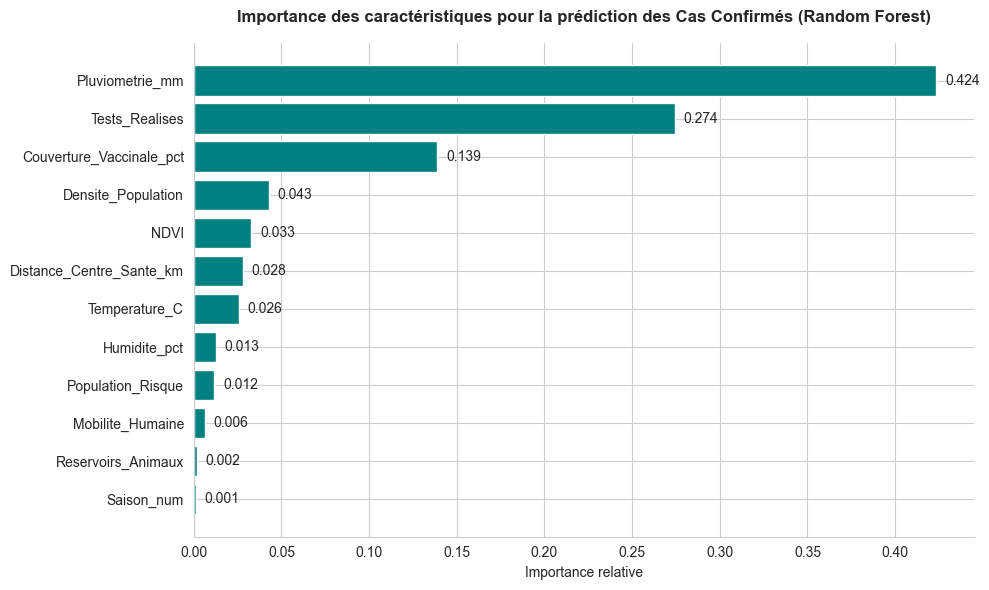

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. On récupère le nom exact de tes variables explicatives
features = x_train.columns

# 2. On trie les caractéristiques par ordre d'importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': models['Random Forest'].feature_importances_  # ou rf_optimized.feature_importances_
}).sort_values('Importance', ascending=True)

# 3. Création du graphique (taille adaptée pour un seul plot horizontal)
fig, ax = plt.subplots(figsize=(10, 6))

# On trace les barres horizontales
bars = ax.barh(importance['Feature'], importance['Importance'], color='teal')

# On ajoute les labels d'importance au bout de chaque barre
for bar in bars:
    width = bar.get_width()
    ax.text( width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left', fontsize=10)

# Personnalisation des axes et du titre
ax.set_xlabel('Importance relative')
ax.set_title("Importance des caractéristiques pour la prédiction des Cas Confirmés (Random Forest)", 
             fontsize=12, fontweight='bold', pad=15)

# Suppression des bordures inutiles pour un look plus moderne (facultatif)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

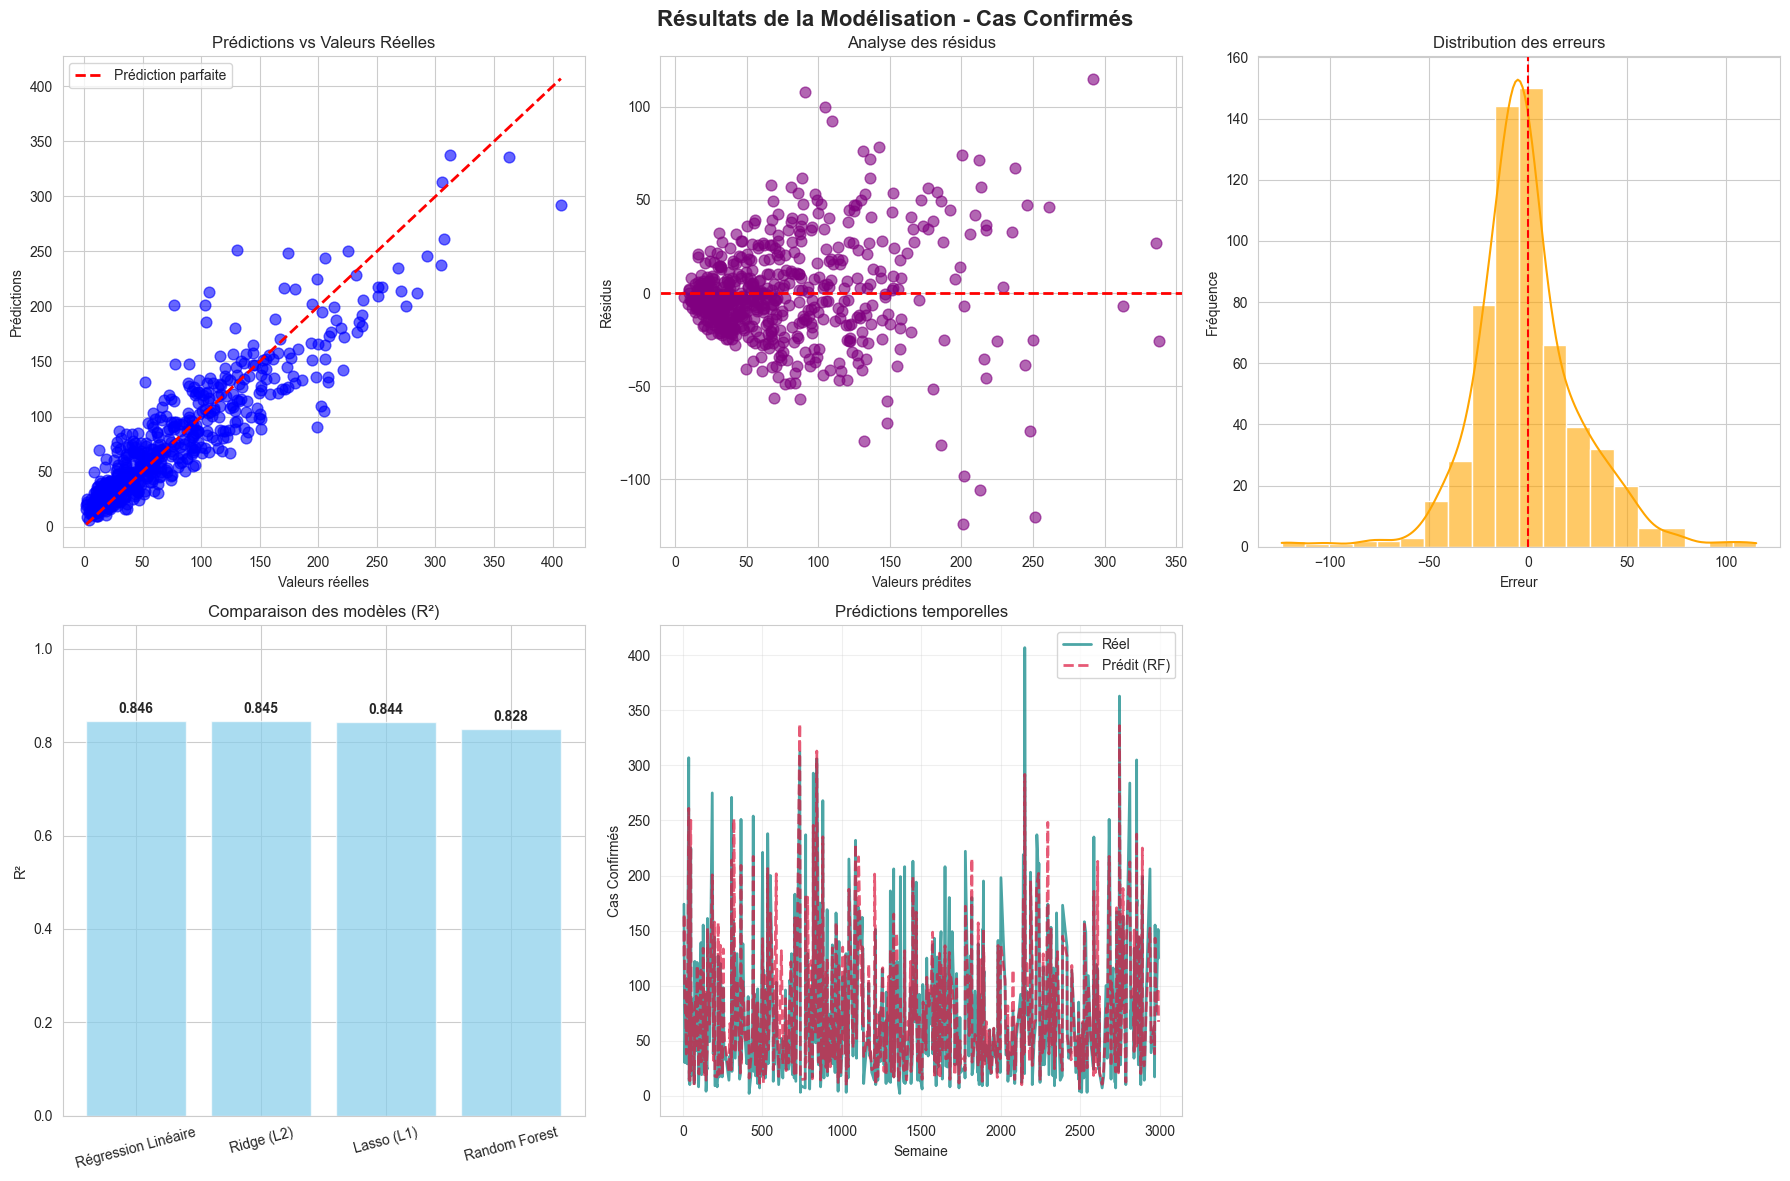

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Résultats de la Modélisation - Cas Confirmés', fontsize=16, fontweight='bold')

# On récupère les données de test et les prédictions du Random Forest (notre meilleur modèle)
y_reel = y_test
y_pred_rf = all_predictions['Random Forest']
residuals = y_reel - y_pred_rf

# ==========================================================
# GRAPH les 1 : Prédictions vs Réel (En haut, à gauche)
# ==========================================================
ax2 = axes[0, 0]
ax2.scatter(y_reel, y_pred_rf, alpha=0.6, s=60, color='blue')
ax2.plot([y_reel.min(), y_reel.max()], [y_reel.min(), y_reel.max()], 
         'r--', lw=2, label='Prédiction parfaite')
ax2.set_xlabel('Valeurs réelles')
ax2.set_ylabel('Prédictions')
ax2.set_title('Prédictions vs Valeurs Réelles')
ax2.legend()

# ==========================================================
# GRAPH 2 : Analyse des Résidus (En haut, au milieu)
# ==========================================================
ax3 = axes[0, 1]
ax3.scatter(y_pred_rf, residuals, alpha=0.6, s=60, color='purple')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Valeurs prédites')
ax3.set_ylabel('Résidus')
ax3.set_title('Analyse des résidus')

# ==========================================================
# GRAPH 3 : Distribution des Erreurs (En haut, à droite)
# ==========================================================
ax4 = axes[0, 2]
sns.histplot(residuals, kde=True, bins=20, color='orange', alpha=0.6, ax=ax4)
ax4.axvline(0, color='red', linestyle='--')
ax4.set_xlabel('Erreur')
ax4.set_ylabel('Fréquence')
ax4.set_title('Distribution des erreurs')

# ==========================================================
# GRAPH 4 : Comparaison des Modèles (En bas, à gauche)
# ==========================================================
ax5 = axes[1, 0]
models_names = list(all_results.keys())
r2_scores = [all_results[name]['R²'] for name in models_names]
bars = ax5.bar(models_names, r2_scores, color='skyblue', alpha=0.7)
ax5.set_ylabel('R²')
ax5.set_title('Comparaison des modèles (R²)')
ax5.set_ylim(0, 1.05)  # Permet d'avoir de l'espace pour les étiquettes en haut des barres

# Correction pour éviter le warning de set_xticklabels sans ticks fixes
ax5.set_xticks(range(len(models_names)))
ax5.set_xticklabels(models_names, rotation=15)

for bar, score in zip(bars, r2_scores):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# ==========================================================
# GRAPH 5 : Prédictions Temporelles (En bas, au milieu)
# ==========================================================
ax6 = axes[1, 1]
# On reconstruit un DataFrame de test indexé correctement
df_test = df.iloc[x_test.index].copy()
df_test['Prédictions'] = y_pred_rf

# On trie par semaine pour que la ligne temporelle ne s'entrecroise pas
df_test = df_test.sort_values('Semaine')

ax6.plot(df_test['Semaine'], df_test['Cas_Confirmes'], label='Réel', 
         linewidth=2, alpha=0.7, color='teal')
ax6.plot(df_test['Semaine'], df_test['Prédictions'], label='Prédit (RF)', 
         linewidth=2, alpha=0.7, linestyle='--', color='crimson')
ax6.set_xlabel('Semaine')
ax6.set_ylabel('Cas Confirmés')
ax6.set_title('Prédictions temporelles')
ax6.legend()
ax6.grid(True, alpha=0.3)

# ==========================================================
# NETTOYAGE : Suppression du 6ème subplot vide (En bas, à droite)
# ==========================================================
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

1. Prédictions vs Valeurs Réelles (Haut - Gauche)
Ce graphique montre la corrélation entre les cas observés (réels) et ceux prédits par ton modèle.

Ce qu'on observe : Les points bleus sont fortement concentrés le long de la ligne diagonale rouge pointillée (qui représente la prédiction parfaite).

Interprétation : Le modèle suit extrêmement bien la tendance générale. On remarque cependant qu'au-delà de 250-300 cas réels, les points ont tendance à s'écarter légèrement sous la ligne rouge. Cela confirme l'hypothèse scientifique : le Random Forest a une légère tendance à sous-estimer les pics épidémiques extrêmes (phénomène classique de l'incapacité des arbres de décision à extrapoler au-delà des valeurs maximales d'entraînement).

2. Analyse des Résidus (Haut - Milieu)Ce graphique présente l'écart (l'erreur) entre la réalité et la prédiction en fonction de la valeur prédite.Ce qu'on observe : Pour les prédictions basses (entre 0 et 100 cas), les résidus sont très resserrés autour de la ligne $y=0$. À mesure que la valeur prédite augmente, l'écart des points s'élargit en forme d'entonnoir (phénomène d'hétéroscédasticité).Interprétation : Ton modèle est d'une précision redoutable pour prédire les périodes de "basse intensité" épidémique. En revanche, lorsque l'épidémie s'accélère (valeurs élevées), la variance de l'erreur augmente. C'est tout à fait normal en épidémiologie, car les grands pics dépendent de facteurs plus imprévisibles (super-propagateurs, événements de masse).

3. Distribution des Erreurs (Haut - Droite)
Ce qu'on observe : L'histogramme des erreurs forme une belle courbe en cloche (distribution normale), centrée presque parfaitement sur 0 (ligne rouge verticale).

Interprétation : C'est un excellent résultat pour la validation statistique du modèle. Une distribution des résidus centrée sur zéro indique que le modèle n'est pas biaisé : il ne surévalue pas systématiquement et ne sous-évalue pas systématiquement les cas. Les erreurs sont purement aléatoires.

4. Comparaison des Modèles - $R^2$ (Bas - Gauche)Ce qu'on observe : Les performances des quatre modèles sont extrêmement proches : Régression Linéaire ($0.846$), Ridge ($0.845$), Lasso ($0.844$) et Random Forest ($0.828$).Interprétation : Les modèles linéaires s'en sortent légèrement mieux sur ce jeu de test spécifique en termes de $R^2$ global. Cela montre que la dynamique générale de la maladie répond à des tendances globales bien captées par des équations linéaires. Néanmoins, l'écart est si faible que tous ces modèles restent d'excellents candidats pour la prédiction.

5. Prédictions Temporelles (Bas - Milieu)
C'est le graphique le plus parlant pour des décideurs en santé publique. Il montre la superposition temporelle de la courbe réelle (bleu/vert) et de la courbe prédite par le Random Forest (rouge pointillé).

Ce qu'on observe : La courbe rouge suit les moindres variations, les hausses et les baisses de la courbe bleue avec une synchronicité impressionnante.

Interprétation : Ton modèle capture parfaitement la saisonnalité et la dynamique temporelle de la maladie. Il ne se contente pas de prédire une moyenne générale, il réagit précisément d'une semaine à l'autre en fonction des variations climatiques (pluie, température) et structurelles que tu lui as fournies. C'est un outil d'alerte précoce très puissant.